# Step 3: Make the hosing forcing

How do I add exactly 0.1, 0.3 or 0.5 Sv of extra freshwater to the subpolar North Atlantic in this model? In this notebook I choose the hosing region, build new freshwater-flux (EmPmR) files that add the extra water evenly over that region, and check by integration that each file adds the intended amount.

I load the libraries and set the paths and choices. The model reads EmPmR from `ncep_emp.bin` in m/s, with positive meaning evaporation (water leaving the ocean), so adding freshwater means a negative anomaly.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from MITgcmutils import rdmds

RUN = os.path.expanduser("~/mitgcm_runs/hosing/spinup")                # spin-up run, for the model grid
ORIGINAL_EMP = os.path.expanduser(
    "~/models/MITgcm/verification/tutorial_global_oce_latlon/input/ncep_emp.bin")   # original freshwater flux
OUT_DIR = "../experiments/hosing_forcing"                                # where the new forcing files go
FIG_DIR = "../figures"
DATA_DIR = "../data"

HOSING_SV = [0.1, 0.3, 0.5]   # extra freshwater input (Sv)
SV = 1.0e6                    # 1 Sv = 1e6 m^3/s
LAT_MIN = 50.0                # hosing region: cell centres from 50°N ...
LAT_MAX = 70.0                # ... to 70°N (cell edges 48°N to 72°N)
LON_WEST = 300.0              # ... east of 60°W (300°E) ...
LON_EAST = 20.0               # ... and west of 20°E
NX, NY, N_MONTHS = 90, 40, 12 # shape of the forcing file
SECONDS_PER_YEAR = 360 * 86400.0

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

I read the model grid: cell centres, cell areas and the open fraction of the top level. The model multiplies EmPmR by the ocean mask (`hFacC > 0` at the surface), so only ocean points count.

In [2]:
xc = rdmds(os.path.join(RUN, "XC"))
yc = rdmds(os.path.join(RUN, "YC"))
rac = rdmds(os.path.join(RUN, "RAC"))        # cell area (m^2)
hfacc = rdmds(os.path.join(RUN, "hFacC"))
ocean = hfacc[0] > 0
atlantic = np.loadtxt(os.path.join(DATA_DIR, "atlantic_mask.csv"), delimiter=",").astype(bool)   # from notebook 02
print("grid", xc.shape, "| ocean points", ocean.sum(), "| Atlantic points", atlantic.sum())

grid (40, 90) | ocean points 2315 | Atlantic points 460


The hosing region is every Atlantic ocean point with its centre between 50°N and 70°N, and between 60°W and 20°E. Using the Atlantic mask keeps Pacific and Arctic points out. The 60°W edge keeps Hudson Bay and Hudson Strait out, while keeping the Labrador Sea, the Irminger Sea and the Nordic Seas, where the model's deep water forms.

In [3]:
region = np.zeros_like(ocean)
for j in range(NY):
    for i in range(NX):
        in_lat = LAT_MIN <= yc[j, i] <= LAT_MAX
        in_lon = (xc[j, i] >= LON_WEST) or (xc[j, i] <= LON_EAST)
        if ocean[j, i] and atlantic[j, i] and in_lat and in_lon:
            region[j, i] = True

region_area = np.sum(rac[region])
print(f"hosing region: {region.sum()} ocean points, area {region_area:.4e} m^2 ({region_area / 1e12:.2f} million km^2)")
np.savetxt(os.path.join(DATA_DIR, "hosing_region_mask.csv"), region.astype(int), fmt="%d", delimiter=",")

hosing region: 87 ocean points, area 8.5023e+12 m^2 (8.50 million km^2)


I plot the region on a map to check it.

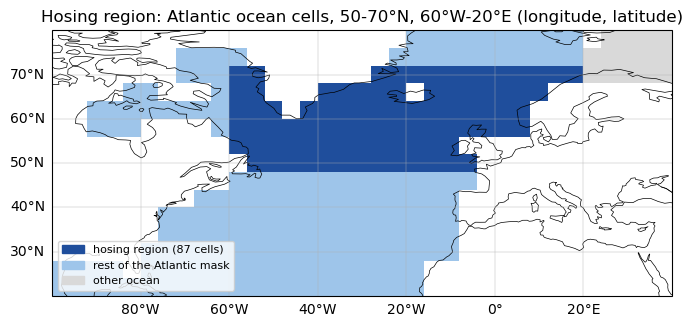

In [4]:
lon_edges = np.arange(0, 361, 4.0)
lat_edges = np.arange(-80, 81, 4.0)
show = np.full(ocean.shape, np.nan)
show[ocean] = 0
show[atlantic] = 1
show[region] = 2

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-30))
cmap = plt.matplotlib.colors.ListedColormap(["#d9d9d9", "#9ec5ea", "#1f4e9c"])
ax.pcolormesh(lon_edges, lat_edges, show, cmap=cmap, vmin=-0.5, vmax=2.5, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([-100, 40, 20, 80], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
for color, label in [("#1f4e9c", f"hosing region ({region.sum()} cells)"), ("#9ec5ea", "rest of the Atlantic mask"),
                     ("#d9d9d9", "other ocean")]:
    ax.fill([], [], color=color, label=label)
ax.legend(loc="lower left", fontsize=8)
ax.set_title("Hosing region: Atlantic ocean cells, 50-70°N, 60°W-20°E (longitude, latitude)")
fig.savefig(os.path.join(FIG_DIR, "03_hosing_region.png"), dpi=150, bbox_inches="tight")
plt.show()

I read the original EmPmR file. It is 12 monthly records of 40 x 90 single-precision, big-endian numbers (`>f4`), which is what `readBinaryPrec=32` in the `data` file expects.

In [5]:
original = np.fromfile(ORIGINAL_EMP, dtype=">f4")
print("values in file:", original.size, "=", N_MONTHS, "x", NY, "x", NX, "->", original.size == N_MONTHS * NY * NX)
original = original.reshape(N_MONTHS, NY, NX)
print(f"original EmPmR range over ocean: {original[:, ocean].min():.3e} to {original[:, ocean].max():.3e} m/s")

values in file: 43200 = 12 x 40 x 90 -> True
original EmPmR range over ocean: -1.796e-07 to 8.936e-08 m/s


For each hosing strength the anomaly is the same in every month and at every region cell: minus the volume flux divided by the region's area. I add it to the original field, so the model still gets its normal freshwater flux plus the hosing, and write the result in the same format.

In [6]:
def hosing_anomaly(strength_sv):
    """EmPmR anomaly (m/s) that adds `strength_sv` of freshwater evenly over the region."""
    flux = -strength_sv * SV / region_area      # negative: water into the ocean
    anomaly = np.zeros((NY, NX))
    anomaly[region] = flux
    return anomaly

file_names = {}
for strength in HOSING_SV:
    anomaly = hosing_anomaly(strength)
    new_field = np.zeros((N_MONTHS, NY, NX))
    for month in range(N_MONTHS):
        new_field[month] = original[month] + anomaly
    name = f"emp_hose{int(round(strength * 100)):03d}.bin"     # e.g. emp_hose010.bin for 0.1 Sv
    new_field.astype(">f4").tofile(os.path.join(OUT_DIR, name))
    file_names[strength] = name
    flux = anomaly[region][0]
    print(f"{strength} Sv -> {name}: anomaly {flux:.4e} m/s = {flux * SECONDS_PER_YEAR:.3f} m of water per year")

0.1 Sv -> emp_hose010.bin: anomaly -1.1762e-08 m/s = -0.366 m of water per year
0.3 Sv -> emp_hose030.bin: anomaly -3.5285e-08 m/s = -1.097 m of water per year
0.5 Sv -> emp_hose050.bin: anomaly -5.8808e-08 m/s = -1.829 m of water per year


Now the check. I read each new file back from disk, subtract the original, and integrate the difference over the model's ocean area, month by month. If everything is right, every month gives the intended number of Sv, apart from tiny rounding because the file stores single-precision numbers, and nothing changed outside the region.

In [7]:
print(f"{'file':18s} {'target (Sv)':>12s} {'min over months':>16s} {'max over months':>16s} {'max |change| outside region':>28s}")
for strength in HOSING_SV:
    new_field = np.fromfile(os.path.join(OUT_DIR, file_names[strength]), dtype=">f4").reshape(N_MONTHS, NY, NX)
    totals = []
    outside = 0.0
    for month in range(N_MONTHS):
        difference = new_field[month].astype(float) - original[month].astype(float)
        totals.append(-np.sum(difference * rac * ocean) / SV)    # minus: freshwater input is positive Sv
        outside = max(outside, np.max(np.abs(difference[~region])))
    print(f"{file_names[strength]:18s} {strength:12.3f} {min(totals):16.8f} {max(totals):16.8f} {outside:28.2e}")

file                target (Sv)  min over months  max over months  max |change| outside region
emp_hose010.bin           0.100       0.10000000       0.10000000                     0.00e+00
emp_hose030.bin           0.300       0.30000000       0.30000000                     0.00e+00
emp_hose050.bin           0.500       0.50000000       0.50000000                     0.00e+00


Finally I check the sizes of the new files against the original, so the model reads them exactly like `ncep_emp.bin`.

In [8]:
print("original:", os.path.getsize(ORIGINAL_EMP), "bytes")
for strength in HOSING_SV:
    path = os.path.join(OUT_DIR, file_names[strength])
    print(f"{file_names[strength]}: {os.path.getsize(path)} bytes")

original: 172800 bytes
emp_hose010.bin: 172800 bytes
emp_hose030.bin: 172800 bytes
emp_hose050.bin: 172800 bytes
